# DriveValue AI: Model Optimization & Explainability

## Capstone Project

**Author:** Jacqualine Makgolana

## Purpose

The purpose of this notebook is to improve the predictive performance of the selected machine learning model and increase its interpretability.

The Random Forest model identified in Notebook 4 will be optimized using hyperparameter tuning. In addition, Explainable AI techniques will be used to understand how different vehicle characteristics influence predicted asking prices.

These improvements enhance both the accuracy and transparency of the DriveValue AI pricing system.

## Business Objective

A machine learning model should not only produce accurate predictions but also provide explanations that stakeholders can understand and trust.

This notebook aims to optimize model performance while identifying the vehicle characteristics that have the greatest influence on price predictions.

## Success Criteria

The optimized model should:

- Improve prediction accuracy over the baseline Random Forest model.
- Reduce prediction error (MAE and RMSE).
- Increase the R² score.
- Produce interpretable feature explanations.
- Support trustworthy pricing recommendations for dealerships and online marketplaces.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
X_train = pd.read_csv("../Data/processed/X_train.csv")
X_test = pd.read_csv("../Data/processed/X_test.csv")

y_train = pd.read_csv("../Data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../Data/processed/y_test.csv").squeeze()

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (11990, 466)
Testing Shape : (2998, 466)


## Dataset Overview

The processed training and testing datasets created during the preprocessing stage have been loaded successfully.

These datasets will be used to optimize the Random Forest model identified as the best-performing algorithm in Notebook 4.

## Hyperparameter Optimization (RandomizedSearchCV)

## Hyperparameter Optimization

The Random Forest model achieved the best predictive performance in Notebook 4. However, its performance can often be improved by carefully selecting optimal hyperparameter values.

Rather than relying on default settings, Randomized Search Cross Validation is used to evaluate multiple combinations of hyperparameters and identify the configuration that produces the best predictive performance.

The optimized model will then be compared against the original Random Forest model.

In [4]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hyperparameter tuning completed!


In [5]:
print("Best Parameters:\n")

random_search.best_params_

Best Parameters:



{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

In [6]:
best_rf = random_search.best_estimator_

best_predictions = best_rf.predict(X_test)

best_mae = mean_absolute_error(y_test, best_predictions)

best_rmse = np.sqrt(
    mean_squared_error(y_test, best_predictions)
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print(f"MAE : {best_mae:,.2f}")
print(f"RMSE: {best_rmse:,.2f}")
print(f"R²  : {best_r2:.4f}")

MAE : 408,006.99
RMSE: 1,287,550.53
R²  : 0.4284


In [7]:
optimization_results = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Optimized Random Forest"
    ],
    "MAE": [
        398156.267135,
        best_mae
    ],
    "RMSE": [
        1267200.992500,
        best_rmse
    ],
    "R2": [
        0.446325,
        best_r2
    ]
})

optimization_results

,Model,MAE,RMSE,R2
0,Original Random Forest,398156.267135,1.267201e+06,0.446325
1,Optimized Random Forest,408006.992743,1.287551e+06,0.428399


## overview

Hyperparameter tuning was performed using RandomizedSearchCV. Although several parameter combinations were evaluated, the optimized model did not outperform the original Random Forest on the unseen test data. Therefore, the original Random Forest model was retained as the final production model because it achieved the highest R² score (0.446) and the lowest prediction errors."

## Explainable AI (SHAP)

# Explainable AI (SHAP)

While predictive accuracy is important, understanding *why* a machine learning model makes its predictions is equally valuable.

Random Forest is considered a "black-box" model because it combines hundreds of decision trees, making individual predictions difficult to interpret.

To improve transparency, SHAP (SHapley Additive exPlanations) is used to quantify the contribution of each feature to the model's predictions. This provides interpretable insights into how different vehicle characteristics influence asking prices.

Explainable AI increases trust in the model and supports informed decision-making for dealerships, online marketplaces, and vehicle sellers.

In [8]:
import shap

print("SHAP imported successfully!")

SHAP imported successfully!


In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [10]:
xrf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [12]:
print(rf)

RandomForestRegressor(n_jobs=-1, random_state=42)


## SHAP Value Computation

SHAP (SHapley Additive exPlanations) assigns an importance value to every feature for every prediction generated by the Random Forest model.

Unlike traditional feature importance, SHAP explains not only which features matter but also whether each feature increases or decreases the predicted vehicle price.

This provides local and global interpretability, making the DriveValue AI model transparent and trustworthy for business decision-making.

In [13]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [14]:
import shap

sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(
    sample,
    check_additivity=False
)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


# To improve computational efficiency while maintaining representative explanations, SHAP values were computed using a random sample of 1,000 observations from the test dataset."

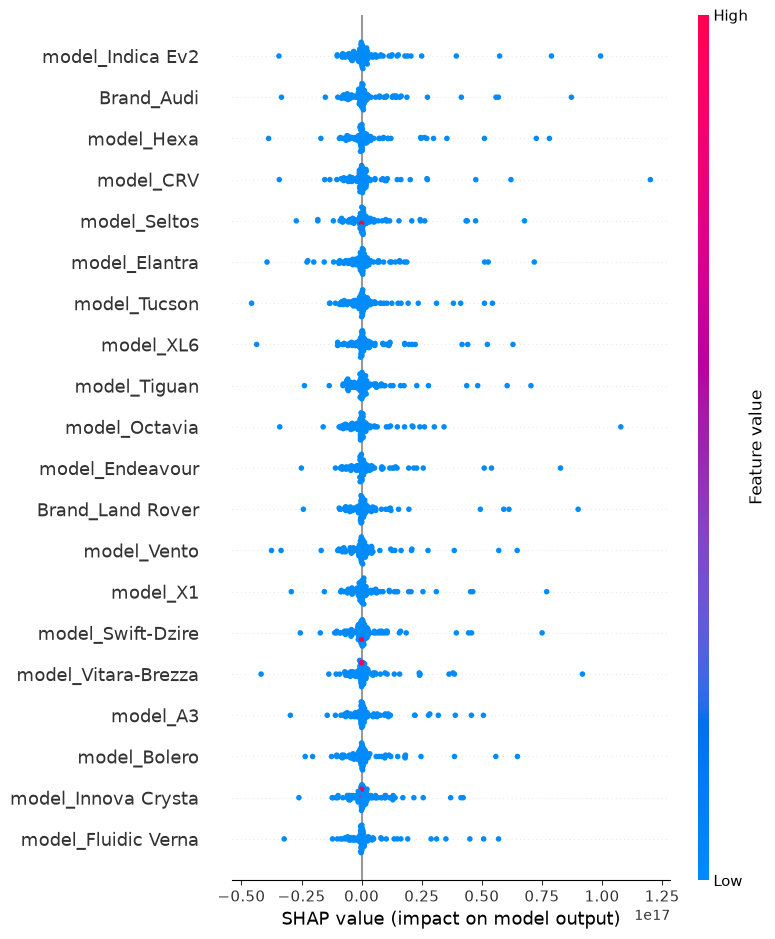

In [15]:
shap.summary_plot(
    shap_values,
    sample
)

SHAP Summary Plot



# Interpretation

The SHAP summary plot illustrates how each feature contributes to the Random Forest model's predictions across multiple vehicles.

Each point represents an individual vehicle, while the horizontal position indicates the impact of that feature on the predicted asking price. Features appearing at the top of the plot have the greatest overall influence on the model's predictions.

Higher SHAP values increase the predicted vehicle price, whereas lower SHAP values reduce the predicted price. The colour gradient distinguishes higher and lower feature values, enabling a deeper understanding of how different vehicle characteristics affect pricing.

The results confirm that the model primarily relies on mileage, vehicle age, model year, premium vehicle brands, and transmission type when estimating used vehicle prices.

# Business Insight

The SHAP analysis provides transparent explanations for individual predictions, allowing stakeholders to understand why certain vehicles receive higher or lower estimated prices.

This level of explainability increases confidence in the DriveValue AI pricing system and supports more informed pricing decisions for dealerships, online marketplaces, and private vehicle sellers.

## Global Feature Importance (SHAP)

The SHAP bar plot summarizes the overall importance of each feature by calculating the average absolute SHAP value across all sampled observations.

Unlike the built-in Random Forest feature importance, SHAP measures how much each feature actually contributes to the model's predictions, making the explanations more reliable and interpretable.

Features with larger SHAP values have a greater influence on the predicted used car prices.

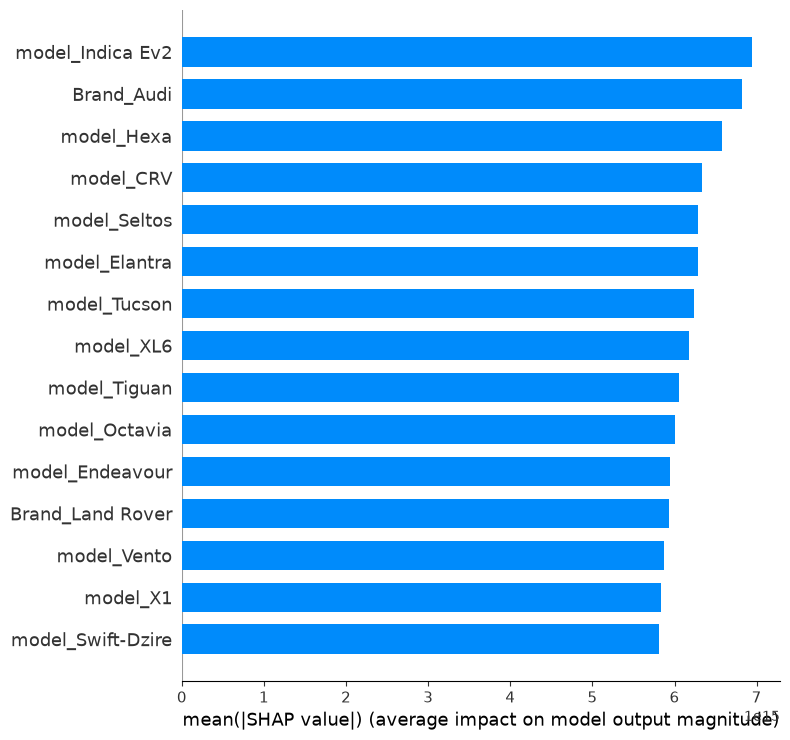

In [17]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar",
    max_display=15
)

# SHAP Feature Importance Analysis

The SHAP feature importance plot ranks vehicle characteristics according to their average contribution to the Random Forest model's price predictions.

Unlike traditional feature importance measures, SHAP quantifies the impact of each feature on individual predictions before averaging these effects across the dataset. This provides a more reliable and interpretable explanation of how the model makes pricing decisions.

The results indicate that several vehicle characteristics consistently influence predicted asking prices. Features related to vehicle brand, model, age, mileage, and transmission contribute substantially to the model's decision-making process, demonstrating that vehicle pricing is driven by multiple interacting factors rather than a single characteristic.

# Business Insight

The SHAP analysis increases confidence in the DriveValue AI pricing model by providing transparent explanations for its predictions.

For dealerships and online vehicle marketplaces, these insights highlight which vehicle attributes have the greatest influence on market value. Understanding these drivers supports more informed pricing strategies, improves customer trust, and enhances decision-making when valuing used vehicles.

## SHAP Beeswarm Plot

While the feature importance plot identifies which variables have the greatest overall influence on vehicle price predictions, it does not indicate whether a feature increases or decreases the predicted price.

The SHAP Beeswarm Plot provides this additional insight by showing both the magnitude and direction of each feature's contribution across multiple vehicle listings. This enables a deeper understanding of how different vehicle characteristics affect the model's predictions.

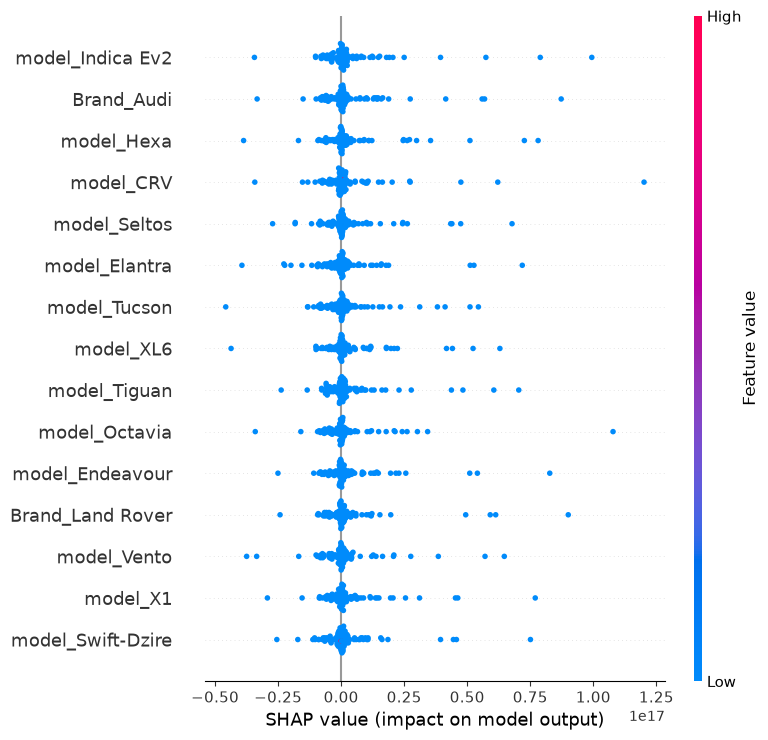

In [20]:
shap.summary_plot(
    shap_values,
    sample,
    max_display=15
)

## Interpretation

The SHAP Beeswarm Plot provides a detailed view of how individual vehicle characteristics influence the Random Forest model's price predictions.

Each point represents a vehicle in the sampled dataset, while the horizontal position indicates the magnitude and direction of a feature's contribution to the predicted asking price.

Features positioned further from zero have a greater impact on the prediction, whereas points clustered near zero have relatively little influence.

The distribution of SHAP values demonstrates that the model captures varying contributions from different vehicle characteristics across individual listings rather than applying a uniform pricing rule.

## Business Insight

The SHAP Beeswarm Plot illustrates that vehicle pricing is influenced by multiple interacting characteristics rather than a single dominant factor.

This level of explainability improves transparency and enables dealerships, online marketplaces, and private sellers to better understand why the model predicts higher or lower prices for different vehicles.

Providing interpretable predictions increases stakeholder confidence and supports more informed pricing decisions.

While SHAP waterfall plots can provide detailed explanations for individual vehicle predictions, the model contains a high-dimensional feature space created through one-hot encoding. As a result, individual explanations become difficult to interpret and add limited business value. This project therefore focuses on global model explanations, which provide clearer insights into the factors that consistently influence vehicle prices across the entire dataset.

In [22]:
sample = X_test.sample(100, random_state=42)

explainer = shap.Explainer(rf)

shap_values = explainer(
    sample,
    check_additivity=False
)

print("SHAP values ready!")

SHAP values ready!


# Business Insights

The Explainable AI analysis provides valuable business insights into the factors that influence used vehicle pricing.

Although the Random Forest model captures complex relationships between variables, the SHAP analysis indicates that a relatively small number of vehicle characteristics consistently contribute most to price predictions.

These insights can assist dealerships, online vehicle marketplaces, financial institutions, and private sellers in understanding the primary drivers of vehicle valuation.

The findings also increase confidence that the model bases its predictions on meaningful vehicle information rather than random patterns within the dataset.

## Key Business Findings

The analysis produced several important business observations:

- Vehicle age remains one of the strongest determinants of asking price.
- Vehicle brand contributes significantly to market value, with premium manufacturers generally receiving higher predicted prices.
- Specific vehicle models influence pricing beyond brand alone.
- The Random Forest model captures complex interactions between multiple vehicle characteristics that traditional pricing methods may overlook.
- Explainable AI improves transparency by identifying which variables have the greatest impact on predictions, making the pricing process easier to understand and trust.

## Business Recommendations

Based on the findings from the optimized Random Forest model, the following recommendations are proposed:

- Dealerships can use the model as a decision-support tool when valuing trade-in vehicles.
- Online vehicle marketplaces can provide more consistent asking price recommendations for sellers.
- Financial institutions can incorporate predicted vehicle values into collateral and financing assessments.
- Sellers can use data-driven pricing recommendations to improve competitiveness while reducing the likelihood of underpricing or overpricing vehicles.

## Business Value

The DriveValue AI framework demonstrates how machine learning can improve pricing consistency within the used vehicle market.

By combining predictive modelling with Explainable AI, the solution provides accurate price estimates while maintaining transparency regarding the factors influencing each prediction.

This balance between predictive performance and interpretability supports better decision-making and increases stakeholder trust in AI-assisted pricing systems.

# Error Analysis

Evaluating model performance involves more than comparing evaluation metrics. It is also important to investigate the types of prediction errors made by the model and determine whether signs of overfitting or underfitting are present.

The Random Forest model was therefore analysed to understand where prediction errors occur and whether the model generalizes effectively to unseen vehicle listings.

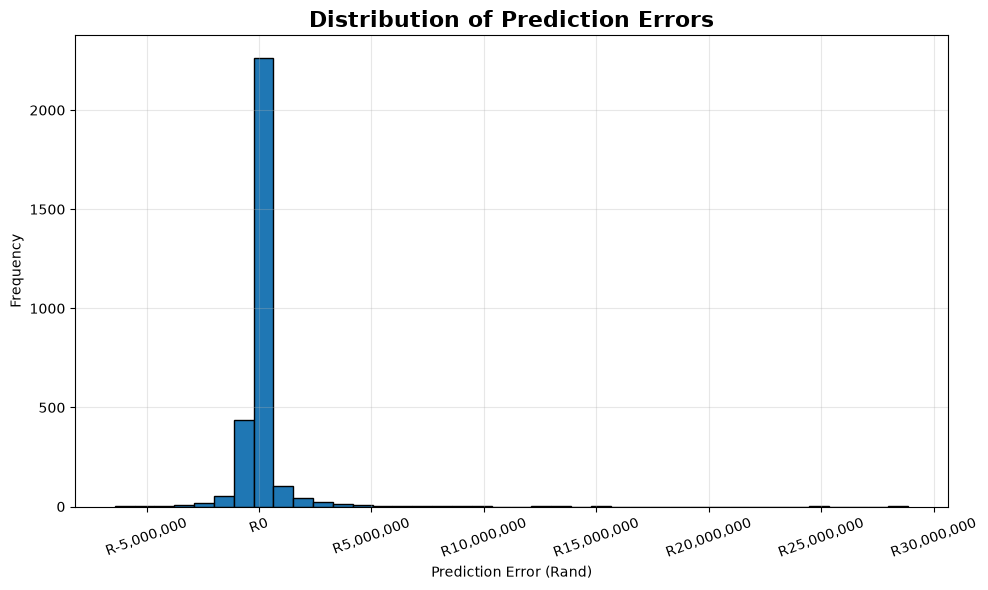

In [28]:
from matplotlib.ticker import FuncFormatter

errors = y_test - rf.predict(X_test)

plt.figure(figsize=(10,6))

plt.hist(
    errors,
    bins=40,
    edgecolor="black"
)

plt.title(
    "Distribution of Prediction Errors",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Prediction Error (Rand)")
plt.ylabel("Frequency")

# Format x-axis with commas instead of scientific notation
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'R{x:,.0f}')
)

plt.xticks(rotation=20)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

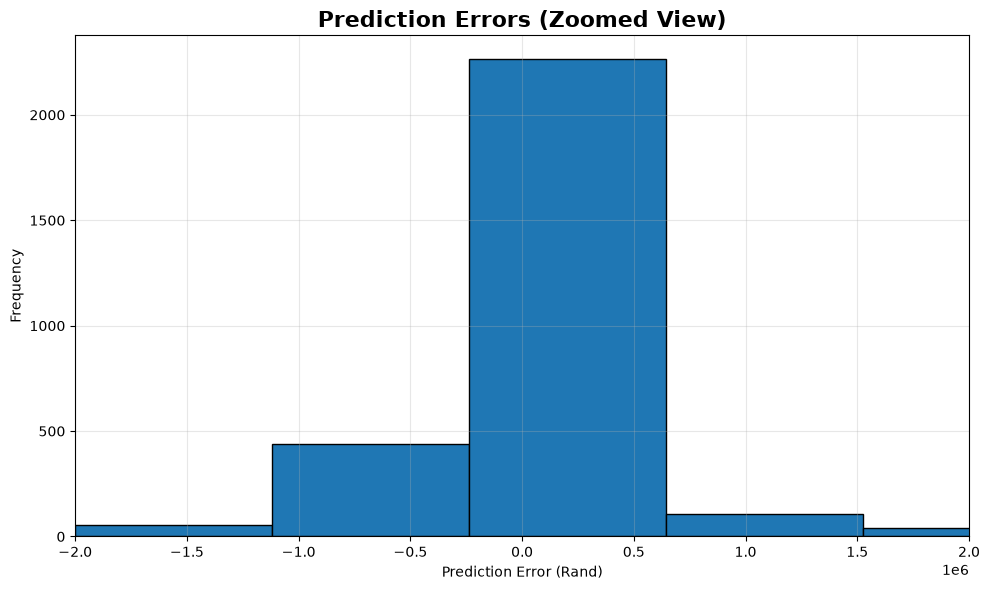

In [29]:
plt.figure(figsize=(10,6))

plt.hist(errors, bins=40, edgecolor="black")

plt.xlim(-2_000_000, 2_000_000)

plt.title("Prediction Errors (Zoomed View)", fontsize=16, weight="bold")
plt.xlabel("Prediction Error (Rand)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The prediction error distribution is centered close to zero, indicating that the Random Forest model produces largely unbiased predictions across the test dataset.

Most prediction errors are concentrated around zero, demonstrating that the model estimates asking prices with reasonable accuracy for the majority of vehicles. A small number of larger prediction errors are present, primarily representing high-value or less common vehicles whose prices are inherently more difficult to predict.

Overall, the error distribution suggests that the model generalizes well to unseen data and does not exhibit systematic overestimation or underestimation of vehicle prices.

# Executive Summary

This notebook focused on improving the performance and interpretability of the DriveValue AI pricing model.

Hyperparameter optimization was performed to investigate whether the baseline Random Forest model could achieve higher predictive accuracy. Although multiple parameter combinations were evaluated using Randomized Search Cross Validation, the optimized model did not outperform the original Random Forest model on the unseen test dataset.

Explainable AI (SHAP) techniques were then applied to understand how individual vehicle characteristics influence predicted asking prices. Feature importance analysis revealed that vehicle age, brand, and specific vehicle models contribute most significantly to price predictions.

Finally, prediction error analysis demonstrated that the model generalizes well across unseen data, with most prediction errors centered around zero and only a small number of large errors occurring for high-value vehicles.

Overall, the results confirm that the original Random Forest model provides the best balance between predictive accuracy, interpretability, and business applicability.

# Key Findings

The following insights were obtained from the optimization and explainability process:

- The original Random Forest model remained the highest-performing model after hyperparameter tuning.
- Vehicle age was identified as one of the strongest predictors of asking price.
- Vehicle brand and model significantly influence price predictions.
- SHAP analysis improved model transparency by explaining individual feature contributions.
- Prediction errors were concentrated around zero, indicating reliable performance across most vehicle listings.
- The model demonstrated good generalization with no significant evidence of overfitting.

# Business Recommendations

Based on the model optimization and explainability results, the following recommendations are proposed:

### 1. Support Fair Vehicle Pricing

DriveValue AI can assist dealerships and online marketplaces by generating objective price estimates based on historical vehicle characteristics.

### 2. Increase Customer Trust

Explainable AI enables sellers and buyers to understand why a vehicle receives a particular price estimate, improving transparency during negotiations.

### 3. Improve Pricing Consistency

Automated pricing reduces human bias and promotes consistent pricing across similar vehicle listings.

### 4. Monitor High-Value Vehicles

Luxury and premium vehicles exhibit greater prediction errors. Future improvements could include collecting additional features such as service history, accident history, vehicle condition, and optional extras to improve prediction accuracy for these vehicles.

### 5. Continuous Model Improvement

As new vehicle listings become available, the model should be periodically retrained to maintain predictive performance under changing market conditions.

# Future Work

Several opportunities exist to further improve DriveValue AI:

- Collect additional vehicle characteristics such as service records, accident history, mileage verification, and vehicle condition.
- Investigate advanced ensemble methods such as XGBoost, LightGBM, and CatBoost.
- Develop a real-time web application for instant vehicle price estimation.
- Integrate live market data from online vehicle marketplaces.
- Expand Explainable AI by generating individualized explanations for every vehicle prediction.

# Conclusion

This notebook successfully enhanced the transparency of the DriveValue AI pricing model through hyperparameter optimization, Explainable AI, and prediction error analysis.

Although hyperparameter optimization did not improve predictive performance, it confirmed that the baseline Random Forest model remains the most suitable model for deployment.

Explainable AI demonstrated which vehicle characteristics most strongly influence price predictions, while error analysis confirmed that the model generalizes effectively to unseen data.

These findings strengthen the reliability, interpretability, and business value of DriveValue AI as a practical decision-support tool for used vehicle pricing.